# A/B Testing Analysis for Marketing Campaign Effectiveness

## Objective

The objective of this project is to determine whether advertisements lead to higher user conversion rates compared to public service announcements (PSA).

The analysis includes:
- Data Cleaning
- Exploratory Data Analysis
- A/B Testing
- Hypothesis Testing
- Business Insights
- Data Visualization

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv("../Data/marketing_AB.csv")
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## Data Cleaning

Before performing the analysis, the dataset is checked for unnecessary columns, missing values, and duplicate records.

In [3]:
df = df.drop(columns=["Unnamed: 0"])

df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


The column `Unnamed: 0` was removed because it is an index column generated during CSV export and does not provide any analytical value.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user id        588101 non-null  int64
 1   test group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total ads      588101 non-null  int64
 4   most ads day   588101 non-null  str  
 5   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB


The dataset contains 588,101 records and 6 columns. No missing values were identified.

In [5]:
df["user id"].duplicated().sum()

np.int64(0)

No duplicate user IDs were found. Each user appears only once, making the dataset suitable for A/B testing analysis.

## Exploratory Data Analysis

This section explores the structure of the experiment, including the distribution of users across test groups and overall conversion behavior.

In [6]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

The experiment contains two groups:

- Advertisement (ad)
- Public Service Announcement (psa)

The ad group contains substantially more users than the PSA group.

In [7]:
df["converted"].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

Out of 588,101 users, 14,843 completed a conversion.

The overall conversion rate is relatively low, which is common in marketing campaigns.

In [8]:
df.groupby("test group")["converted"].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

The advertisement group achieved a higher conversion rate (2.55%) than the PSA group (1.79%).

This suggests that advertisements may be more effective at driving conversions.

## Hypothesis Testing

To determine whether the difference in conversion rates between the advertisement group and the PSA group is statistically significant, a Two-Proportion Z-Test is performed.

### Null Hypothesis (H₀)
There is no difference in conversion rates between the advertisement and PSA groups.

### Alternative Hypothesis (H₁)
There is a significant difference in conversion rates between the advertisement and PSA groups.

In [9]:
count = [14423, 420]
nobs = [564577, 23524]

count, nobs

([14423, 420], [564577, 23524])

The test requires:

- Number of conversions in each group
- Total number of users in each group

In [20]:
z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 7.3700781265454145
P-value: 1.7052807161559727e-13


### Interpretation

The p-value is significantly smaller than the commonly used significance level of 0.05.

Therefore, the null hypothesis is rejected.

This indicates that the difference in conversion rates between the advertisement and PSA groups is statistically significant.

In [11]:
ad_rate = 2.554656
psa_rate = 1.785411

lift = ((ad_rate - psa_rate) / psa_rate) * 100

print(f"Lift: {lift:.2f}%")

Lift: 43.09%


The advertisement campaign generated a 43.09% improvement in conversion rate compared to the PSA campaign.

## Data Visualization

The following visualizations were created to better understand conversion behavior across test groups, ad exposure levels, days, and hours.

###  1.Conversion Rate by Test Group

This visualization compares conversion rates between users exposed to advertisements and users exposed to PSA messages.

In [23]:
conversion_rate = (df.groupby("test group")['converted'].mean().reset_index())
conversion_rate['converted'] = conversion_rate['converted']*100
conversion_rate


,test group,converted
0,ad,2.554656
1,psa,1.785411


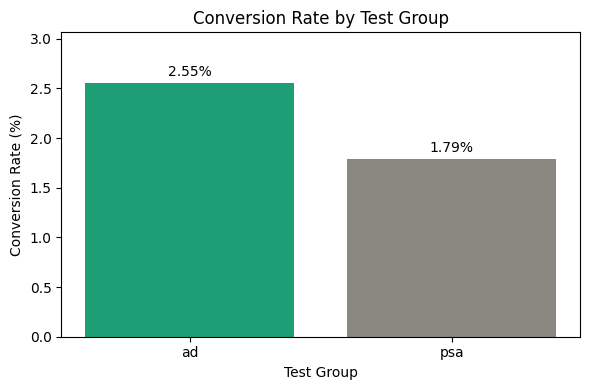

In [ ]:
plt.figure(figsize=(6, 4))

colors = ['#1D9E75', '#888780']
bars = plt.bar(
    conversion_rate["test group"].astype(str),
    conversion_rate["converted"],
    color=colors
)

plt.bar_label(bars, fmt='%.2f%%', padding=3)
plt.title("Conversion Rate by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, conversion_rate["converted"].max() * 1.2)
plt.tight_layout()
plt.show()

### Interpretation

The advertisement group achieved a conversion rate of 2.55%, compared to 1.79% for the PSA group.

This indicates that users exposed to advertisements converted at a higher rate than users exposed to PSA messages.

### 2. Conversion Rate by Ad Exposure

This visualization shows how conversion rates change as users are exposed to increasing numbers of advertisements.

In [13]:
df["ad_bucket"] = pd.cut(
    df["total ads"],
    bins=[0, 10, 30, 100, 300, 2100],
    labels=["1-10", "11-30", "31-100", "101-300", "300+"]
)

ad_bucket_conversion = (
    df.groupby("ad_bucket")["converted"]
    .mean()
    .reset_index()
)

ad_bucket_conversion["converted"] = ad_bucket_conversion["converted"] * 100

ad_bucket_conversion

,ad_bucket,converted
0,1-10,0.329019
1,11-30,1.166292
2,31-100,7.238798
3,101-300,17.012629
4,300+,15.978306


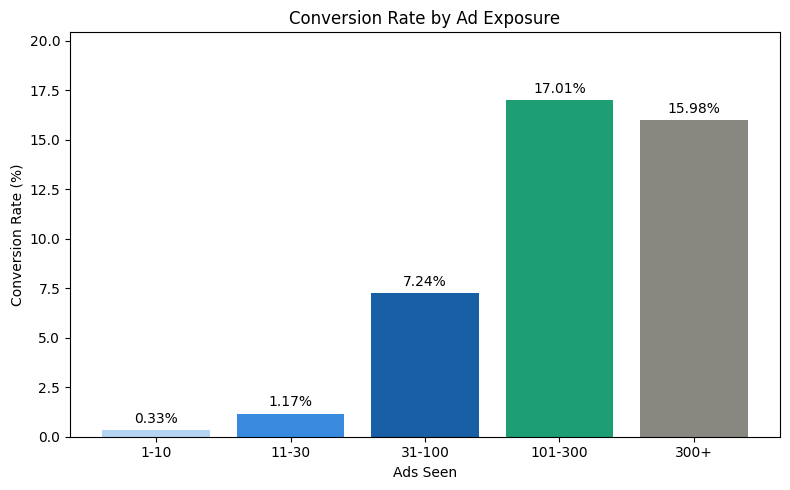

In [28]:
plt.figure(figsize=(8, 5))

colors = ['#B5D4F4', '#378ADD', '#185FA5', '#1D9E75', '#888780']
bars = plt.bar(
    ad_bucket_conversion["ad_bucket"].astype(str),
    ad_bucket_conversion["converted"],
    color=colors
)

plt.bar_label(bars, fmt='%.2f%%', padding=3)
plt.title("Conversion Rate by Ad Exposure")
plt.xlabel("Ads Seen")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, ad_bucket_conversion["converted"].max() * 1.2)
plt.tight_layout()
plt.show()

### Interpretation

Conversion rates increase significantly as ad exposure increases. The highest conversion rate was observed among users exposed to 101–300 advertisements. Beyond this level, conversion rates decline slightly, suggesting possible ad fatigue.

### 3. Conversion Rate by Day

This visualization identifies which days of the week generate the highest conversion rates.

In [15]:
day_conversion = (
    df.groupby("most ads day")["converted"]
    .mean()
    .reset_index()
)

day_conversion["converted"] = day_conversion["converted"] * 100

day_conversion = day_conversion.sort_values(
    by="converted",
    ascending=False
)

day_conversion

,most ads day,converted
1,Monday,3.281155
5,Tuesday,2.984034
6,Wednesday,2.494191
3,Sunday,2.447565
0,Friday,2.221190
4,Thursday,2.157094
2,Saturday,2.105070


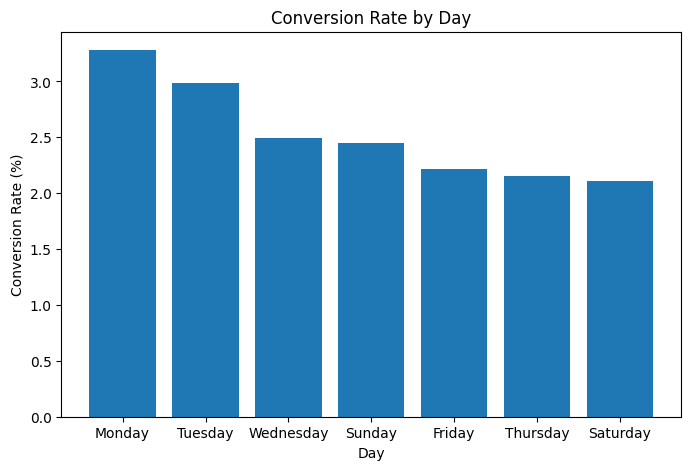

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    day_conversion["most ads day"],
    day_conversion["converted"]
)

plt.title("Conversion Rate by Day")
plt.xlabel("Day")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Interpretation

Monday and Tuesday achieved the highest conversion rates among all days of the week. This suggests that marketing campaigns launched early in the week may generate better results compared to campaigns launched later in the week.

### 4. Conversion Rate by Hour

This visualization examines how conversion rates vary throughout the day and helps identify the most effective time periods for displaying advertisements.

In [18]:
hour_conversion = (
    df.groupby("most ads hour")["converted"]
    .mean()
    .reset_index()
)

hour_conversion["converted"] = (
    hour_conversion["converted"] * 100
)

hour_conversion = hour_conversion.sort_values(
    by="most ads hour"
)

hour_conversion.head()

,most ads hour,converted
0,0,1.842486
1,1,1.291129
2,2,0.731296
3,3,1.045166
4,4,1.523546


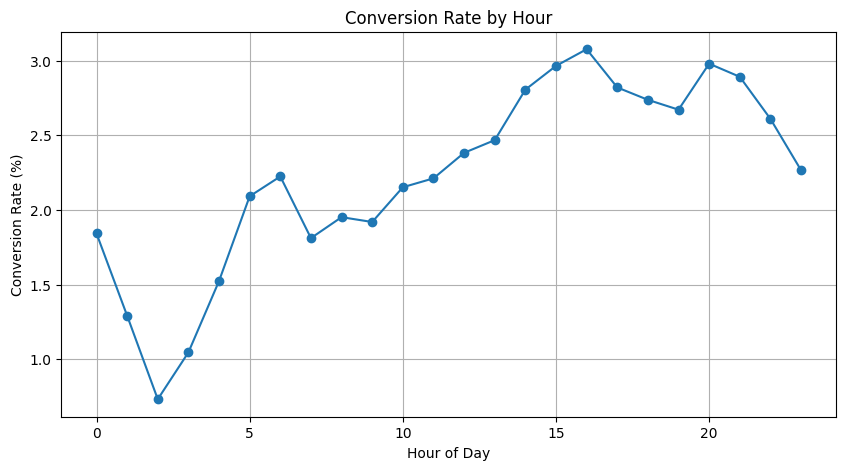

In [30]:
plt.figure(figsize=(10,5))

plt.plot(
    hour_conversion["most ads hour"],
    hour_conversion["converted"],
    marker="o"
)

plt.title("Conversion Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Conversion Rate (%)")

plt.grid(True)

plt.show()

### Interpretation

Conversion rates generally increase throughout the day and peak during the afternoon and evening hours. The highest conversion rates were observed around 4 PM, with strong performance between 4 PM and 9 PM.

This suggests that scheduling advertisements during these hours may improve campaign effectiveness and return on investment.

## Key Findings

1. The advertisement group achieved a conversion rate of 2.55%, compared to 1.79% for the PSA group.

2. The advertisement campaign generated a 43.09% lift in conversion rate.

3. The Two-Proportion Z-Test produced a p-value of 1.70e-13, indicating that the difference is statistically significant.

4. Users exposed to 101–300 advertisements achieved the highest conversion rate (17.01%).

5. Monday and Tuesday were the highest-converting days.

6. The highest conversion rates were observed between 4 PM and 9 PM.

## Business Recommendations

1. Continue using advertisements instead of PSA campaigns, as advertisements significantly improve conversion rates.

2. Focus campaign delivery during high-performing hours (4 PM – 9 PM).

3. Prioritize marketing spend on Monday and Tuesday, which demonstrated the highest conversion rates.

4. Optimize ad frequency around the 101–300 exposure range, where conversion rates peaked.

5. Monitor users exposed to more than 300 advertisements, as conversion rates begin to decline, suggesting possible ad fatigue.